In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
from astropy.table import Table
import pickle
import pandas as pd
import SyntheticData as sd
import Sampler
from datetime import datetime, date
import corner
from utils.utils import *
import style

/home/bepennell/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
indices = [0,5,7,9,12]
all_mdwarfs = []
relevant_list = ["parallax", "mass", "phot_g_mean_mag", "solution_type"]

mdwarfs = Table.read('./data/50_200pc_mdwarfs_reduced.fits', format='fits')
masses = np.array([row["mass_single"] for row in mdwarfs])
percs = np.percentile(masses, np.arange(0, 110, 10))
for row in tqdm(mdwarfs):
    df = dict()
    df["soltype_index"] = indices.index(row["solution_type"])   
    df["mass_index"] = np.minimum(np.digitize(row["mass_single"], percs) - 1, 9)
    for item in relevant_list:
        working_item = item
        if item == "mass":
            working_item = "mass_single"
        df[item] = float(row[working_item])
    all_mdwarfs.append(df)
all_mdwarfs = np.array(all_mdwarfs)

  0%|          | 0/259668 [00:00<?, ?it/s]

In [3]:
indata = pickle.load(open("./massive_data/2026-03-23-mod_reference_vol.pkl", "rb"))["data"]
sc_cubes = pickle.load(open("./data/2026-03-19-mass_binned_mod_mdwarfs.pkl", "rb"))

In [4]:
reduced_catalogue = []
for row in tqdm(indata):
    df = dict()
    df["soltype_index"] = indices.index(row["solution_type"])   
    df["mass_index"] = np.minimum(np.digitize(row["mass"], percs) - 1, 9)
    for item in relevant_list:
        working_item = item
        df[item] = float(row[working_item])
    reduced_catalogue.append(df)
reduced_catalogue = np.array(reduced_catalogue)

  0%|          | 0/250000 [00:00<?, ?it/s]

In [55]:
fb = 0.19
grid_shape = (25,15)
model_cube = Sampler.create_model_cube(grid_shape, p_model=(4,1.3), q_model=0.5)

In [ ]:
small_ms = reduced_catalogue[[a["mass_index"] == 0 for a in reduced_catalogue]]
p_boundaries = np.linspace(1,8, grid_shape[0]+1)[1:-1]
q_boundaries = np.linspace(0.05,0.5, grid_shape[1]+1)[1:-1]
grids = Sampler.compute_grids(small_ms, sc_cubes, period_boundaries=p_boundaries, m_boundaries=q_boundaries, q_space=True, mass_binned=True, all=True)

In [68]:
synthsampler = Sampler.popsampler(sc_cubes, small_ms, model_cube=model_cube)
fbs, likelihoods = synthsampler.binarity(resolution=1000, catalogue=small_ms, mass_binned=True)

Reducing catalogue...
Computing grids...


  0%|          | 0/25011 [00:00<?, ?it/s]

Computing likelihoods...


  0%|          | 0/1000 [00:00<?, ?it/s]

In [70]:
fb = fbs[np.argmax(likelihoods)]
fb

np.float64(0.3467267267267267)

In [71]:
counts = Sampler.expected_counts(fb, grids, model_cube)

In [72]:
t_loaded = small_ms
rates = [len(t_loaded[[t["solution_type"] == soltype for t in t_loaded]])/len(t_loaded)*100 for soltype in [0,5,7,9,12]]
grid = [
    rates,
    [int(grp/100*len(t_loaded)) for grp in rates],
    np.floor(np.sum(counts, axis=0))
]
row_labels = ["Rate (%)", "Counts", "Fits"]
col_labels = ["low RUWE", "high RUWE", "Acceleration", "Jerk", "Full Orbit"]
df = pd.DataFrame(grid, index=row_labels, columns=col_labels)
print("Old scheme")
df.style.format(
    "{:.0f}",
    subset=pd.IndexSlice[["Counts", "Fits"], :]
).format(
    "{:.2f}",
    subset=pd.IndexSlice["Rate (%)", :]
)

Old scheme


,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
Rate (%),95.51,1.56,1.18,0.46,1.29
Counts,23889,391,294,114,323
Fits,23884,418,297,94,316


### Real data

In [ ]:
real_small_ms = all_mdwarfs[[a["mass_index"] == 0 for a in all_mdwarfs]]
p_boundaries = np.linspace(1,8, grid_shape[0]+1)[1:-1]
q_boundaries = np.linspace(0.05,0.5, grid_shape[1]+1)[1:-1]
real_grids = Sampler.compute_grids(real_small_ms, sc_cubes, period_boundaries=p_boundaries, m_boundaries=q_boundaries, q_space=True, mass_binned=True, all=True)

  0%|          | 0/25967 [00:00<?, ?it/s]

In [60]:
synthsampler = Sampler.popsampler(sc_cubes, real_small_ms, model_cube=model_cube)
fbs, likelihoods = synthsampler.binarity(resolution=1000, catalogue=real_small_ms, mass_binned=True)

Reducing catalogue...
Computing grids...


  0%|          | 0/25967 [00:00<?, ?it/s]

Computing likelihoods...


  0%|          | 0/1000 [00:00<?, ?it/s]

In [63]:
fb = fbs[np.argmax(likelihoods)]

In [64]:
real_counts = Sampler.expected_counts(fb, real_grids, model_cube)

In [67]:
t_loaded = real_small_ms
rates = [len(t_loaded[[t["solution_type"] == soltype for t in t_loaded]])/len(t_loaded)*100 for soltype in [0,5,7,9,12]]
grid = [
    rates,
    np.sum(real_counts, axis=0)*100/len(t_loaded),
    np.sum(counts, axis=0)*100/len(small_ms),
]
row_labels = ["True Rate (%)", "Fits Real (%)", "Fits Synthetic (%)"]
col_labels = ["low RUWE", "high RUWE", "Acceleration", "Jerk", "Full Orbit"]
df = pd.DataFrame(grid, index=row_labels, columns=col_labels)
df.style.format(
    "{:.2f}",
    subset=pd.IndexSlice[row_labels, :]
)

,low RUWE,high RUWE,Acceleration,Jerk,Full Orbit
True Rate (%),97.89,1.88,0.15,0.03,0.05
Fits Real (%),97.88,0.79,0.56,0.18,0.59
Fits Synthetic (%),97.53,0.92,0.65,0.21,0.69


## For all the objects

In [73]:
percentiles = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
masses = np.array([t["mass"] for t in all_mdwarfs])
mass_lims = np.percentile(masses, percentiles) 
def convert_to_usable(sc_cubes, mass_index):
    out_sc_cube = {}
    out_sc_cube["data"] = sc_cubes["data"][mass_index]
    out_sc_cube["meta"] = {}
    out_sc_cube["meta"]["shape"] = sc_cubes["meta"]["shape"]
    out_sc_cube["meta"]["lambdas"] = np.array(sc_cubes["meta"]["lambdas"][mass_index])
    out_sc_cube["meta"]["periods"] = sc_cubes["meta"]["periods"]
    out_sc_cube["meta"]["parallaxes"] = sc_cubes["meta"]["parallaxes"]
    return out_sc_cube

def mass_binned_data(sc_cubes, catalogue, mass_binned=False, p_model=(4,2), pcut=None, q_model=0, model_cube_size=(15,15), scale=5):
    synth_results = []
    likelihood_set = []

    for mass_index in tqdm(range(len(mass_lims))):
        temp_catalogue = []
        for _, obj in enumerate(catalogue):
            if mass_index == 0:
                if obj["mass"] < mass_lims[0]:
                    temp_catalogue.append(obj)
            else:
                if (mass_lims[mass_index-1] < obj["mass"]) & (obj["mass"] <= mass_lims[mass_index]):
                    temp_catalogue.append(obj)
        
        # reduce to only mandatory objects to save on memory
        working_catalogue = []
        relevant_list = ["parallax", "mass", "phot_g_mean_mag", "solution_type"]
        for row in temp_catalogue:
            df = dict()
            df["mass_index"] = mass_index
            for item in relevant_list:
                df[item] = float(row[item])
            working_catalogue.append(df)
        
        model_cube = Sampler.create_model_cube(model_cube_size, p_model=p_model, q_model=q_model, pcut=pcut)
        out_sc_cube = sc_cubes
        if mass_binned:
            out_sc_cube = convert_to_usable(sc_cubes, mass_index)
        synthsampler = Sampler.popsampler(out_sc_cube, working_catalogue, model_cube=model_cube)
        _, likelihoods = synthsampler.binarity(resolution=2500, scale=scale, verbose=False)
        likelihood_set.append(likelihoods)
        synth_results.append(synthsampler.fb_estimator())
        print(f'{synthsampler.fb_estimator()[0]*100:.2f}')
    synth_results = np.array(synth_results)
    likelihood_set = np.array(likelihood_set)
    return synth_results, likelihood_set

In [74]:
sc_cubes = pickle.load(open("./data/2026-03-19-mass_binned_mod_mdwarfs.pkl", "rb"))
synth_results, likelihood_set = mass_binned_data(sc_cubes, all_mdwarfs, mass_binned=True, p_model=(4,1.3), q_model=0.5, model_cube_size=(25,15), scale=3)

  0%|          | 0/10 [00:00<?, ?it/s]

16.29
18.48
21.44
21.75
22.86
23.97
26.01
26.28
25.82
24.36


In [80]:
fbs = []
for a in all_mdwarfs:
    fbs.append(synth_results[:,0][a["mass_index"]])
fbs = np.array(fbs)

In [ ]:
p_boundaries = np.linspace(1,8, grid_shape[0]+1)[1:-1]
q_boundaries = np.linspace(0.05,0.5, grid_shape[1]+1)[1:-1]
real_grids = Sampler.compute_grids(all_mdwarfs, sc_cubes, period_boundaries=p_boundaries, m_boundaries=q_boundaries, q_space=True, mass_binned=True, all=True)

In [90]:
def expected_counts(fb, grids, model_cube): 
    ravelled_model_cube = model_cube.ravel()
    
    grids = grids.reshape((len(grids), len(ravelled_model_cube), 5)) # (#objects, grid_size, 5)
    grids = np.swapaxes(grids, 1, 2)
    
    dot_values = fbs[:, None].repeat(5, axis=1) * np.dot(grids, ravelled_model_cube) # (#objects, 5)

    # For solution_type == 0, add single star component (1 - fb)
    dot_values[:,0] += (1 - fb)
    
    # Apply cutoff and sum log-likelihoods
    return dot_values

real_counts = expected_counts(fbs, real_grids, model_cube)

In [91]:
real_counts

array([[0.97044251, 0.01048467, 0.00789429, 0.00261977, 0.00855876],
       [0.97316392, 0.0106134 , 0.00670935, 0.0020332 , 0.00748013],
       [0.94025245, 0.01782105, 0.01641333, 0.00673956, 0.0187736 ],
       ...,
       [0.97981473, 0.00752998, 0.00535184, 0.0016567 , 0.00564675],
       [0.95349653, 0.01604239, 0.01231707, 0.00455947, 0.01358454],
       [0.96917436, 0.01184274, 0.00802685, 0.00242718, 0.00852886]],
      shape=(259668, 5))

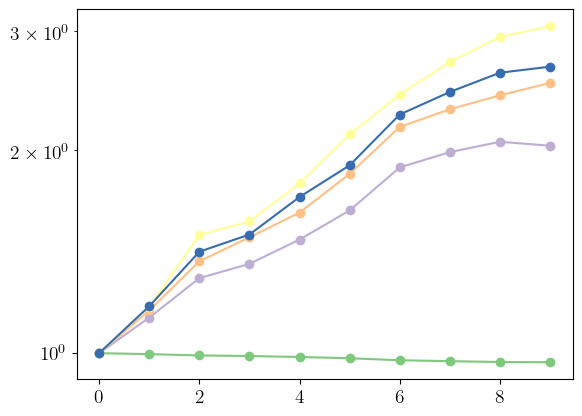

In [101]:
counts = np.zeros((10, 5))
for i in range(10):
    obj_mask = np.array([a["mass_index"] == i for a in all_mdwarfs])
    current_objects = real_counts[obj_mask]
    counts[i,:] = np.sum(current_objects, axis=0)/len(current_objects)

solution_colormap = plt.get_cmap('Accent')(np.linspace(0, 1, 8))[:5]
CMAP = matplotlib.colors.ListedColormap(solution_colormap)

for i in range(5):
    plt.plot(counts[:,i]/counts[0,i], color=solution_colormap[i], marker="o");
plt.yscale("log");

In [103]:
objs = [[],[],[],[],[]]
for obj in all_mdwarfs:
    mass = obj["mass"]
    if mass <= mass_lims[0]:
        objs[0].append(obj)
    elif mass <= mass_lims[1]:
        objs[1].append(obj)
    elif mass <= mass_lims[2]:
        objs[2].append(obj)
    elif mass <= mass_lims[3]:
        objs[3].append(obj)
    else:
        objs[4].append(obj)

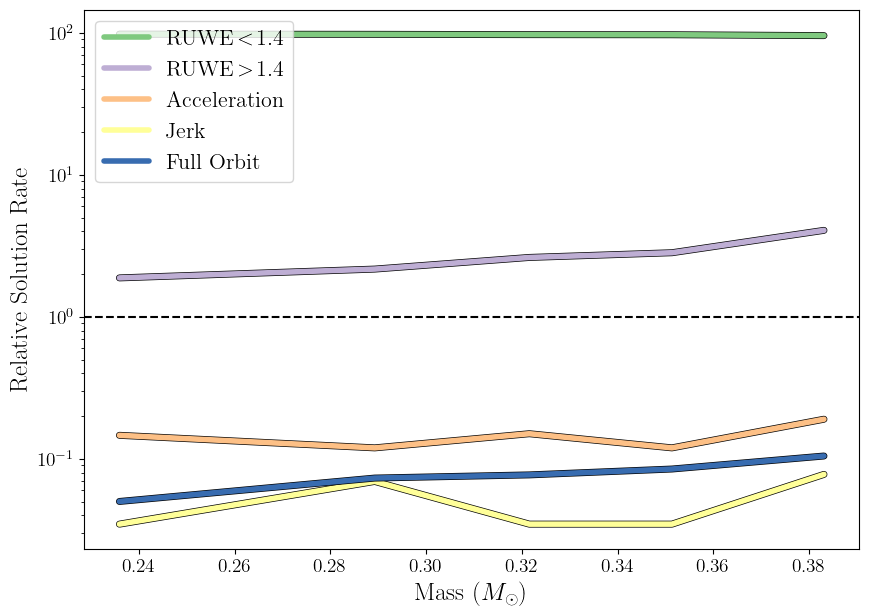

In [112]:
percentiles_b = np.array([0, 20, 40, 60, 80, 100])
masses = np.array([t["mass"] for t in all_mdwarfs])
mass_lims_b = np.percentile(masses, percentiles_b)
bin_centers = (mass_lims_b[1:] + mass_lims_b[:-1]) / 2

fig, ax = plt.subplots(1,1, figsize=(10,7))
rates = np.zeros((5,5))
errs = np.zeros((5,5))
soltypes = [0,5,7,9,12]
for i in range(5):
    counts = np.zeros(5)
    for obj in objs[i]:
        counts[soltypes.index(obj["solution_type"])] += 1
    rates[i] = counts / len(objs[i]) * 100
    errs[i] = np.sqrt(counts) / len(objs[i]) * 100

# Add Poisson error bands
# for j in range(5):
#     poisson_errors = errs[:,j]
#     ax.fill_between(bin_centers, 
#                      (rates[:, j] - poisson_errors) / rates[0, j],
#                      (rates[:, j] + poisson_errors) / rates[0, j],
#                      alpha=0.5, color=solution_colormap[j])

labels = [r"$\text{RUWE}\!<\!1.4$", r"$\text{RUWE}\!>\!1.4$", 'Acceleration', 'Jerk', 'Full Orbit']
for i in range(5):
    ax.plot(bin_centers, rates[:,i], c="k", linewidth=5, solid_capstyle='round', zorder=i+1);
    ax.plot(bin_centers, rates[:,i], c=solution_colormap[i], linewidth=4, solid_capstyle='round', label=labels[i], zorder=i+1);
ax.legend();
plt.yscale("log")
ax.axhline(y=1, color='k', linestyle='--', zorder=0);
ax.set_xlabel("Mass ($M_\\odot$)");
ax.set_ylabel("Relative Solution Rate");
#plt.savefig("../plots/solution_rate_vs_mass.pdf", bbox_inches='tight', dpi=800);

In [116]:
mdwarf_table = Table()
relevant_list = ["parallax", "mass", "phot_g_mean_mag", "solution_type"]
for item in relevant_list:
    mdwarf_table[item] = [float(row[item]) for row in all_mdwarfs]

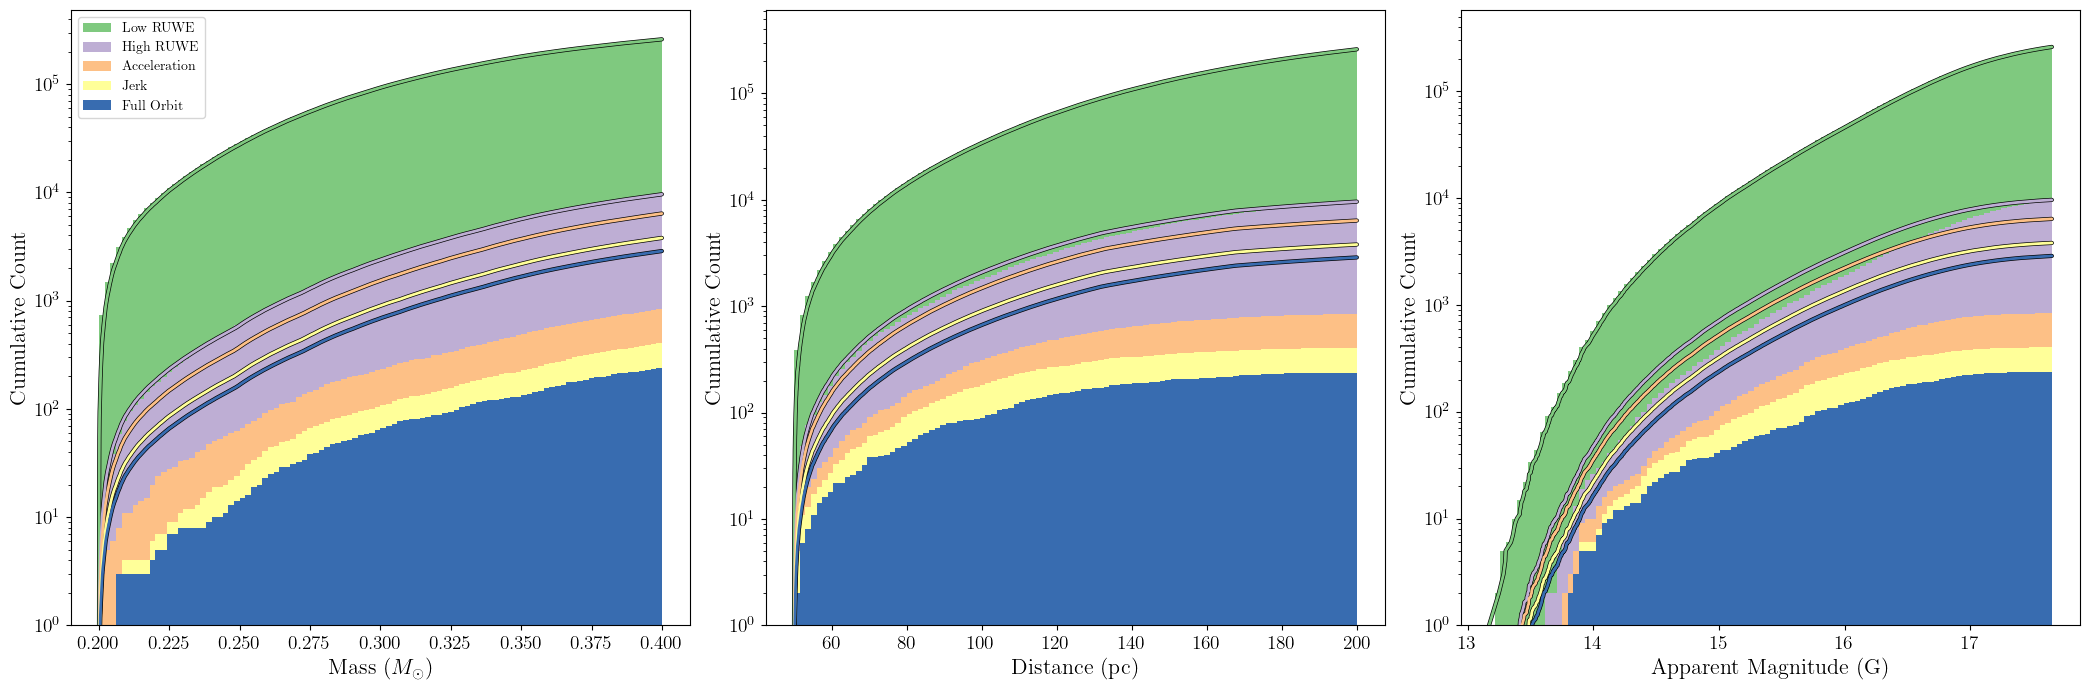

In [154]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from scipy.stats import gaussian_kde

fig, axs = plt.subplots(1, 3, figsize=(21, 7))
labelsize = 16
bin_count = 100

def plot_outlined(ax, x, y, c):
        ax.plot(x, y, lw=2, c=c, zorder=3, solid_capstyle='round');
        ax.plot(x, y, lw=3, c="k", zorder=2, solid_capstyle='round');

# ------------------------------------------
# Top-right: MASS HISTOGRAM
# ------------------------------------------
ax = axs[0]
tbins = ax.hist(mdwarf_table["mass"], color=solution_colormap[0], bins=bin_count, label="Low RUWE", cumulative=True)
ax.hist(mdwarf_table[np.isin(mdwarf_table["solution_type"], [5, 7, 9, 12])]["mass"],
        bins=tbins[1], color=solution_colormap[1], label="High RUWE", cumulative=True)
ax.hist(mdwarf_table[np.isin(mdwarf_table["solution_type"], [7, 9, 12])]["mass"],
        bins=tbins[1], color=solution_colormap[2], label="Acceleration", cumulative=True)
ax.hist(mdwarf_table[np.isin(mdwarf_table["solution_type"], [9, 12])]["mass"],
        bins=tbins[1], color=solution_colormap[3], label="Jerk", cumulative=True)
ax.hist(mdwarf_table[mdwarf_table["solution_type"] == 12]["mass"],
        bins=tbins[1], color=solution_colormap[4], label="Full Orbit", cumulative=True)
ax.set_yscale("log")
ax.set_xlabel(r"Mass ($M_\odot$)", fontsize=labelsize)
ax.set_ylabel(r"Cumulative Count", fontsize=labelsize)
ax.set_ylim(bottom=1)

msorted_counts = real_counts[np.argsort(mdwarf_table["mass"])]
plot_outlined(ax, np.sort(mdwarf_table["mass"]), np.cumsum(np.sum(msorted_counts[:,[0,1,2,3,4]], axis=1)), c=solution_colormap[0]);
plot_outlined(ax, np.sort(mdwarf_table["mass"]), np.cumsum(np.sum(msorted_counts[:,[1,2,3,4]], axis=1)), c=solution_colormap[1]);
plot_outlined(ax, np.sort(mdwarf_table["mass"]), np.cumsum(np.sum(msorted_counts[:,[2,3,4]], axis=1)), c=solution_colormap[2]);
plot_outlined(ax, np.sort(mdwarf_table["mass"]), np.cumsum(np.sum(msorted_counts[:,[3,4]], axis=1)), c=solution_colormap[3]);
plot_outlined(ax, np.sort(mdwarf_table["mass"]), np.cumsum(msorted_counts[:,4]), c=solution_colormap[4]);

ax.legend(fontsize=10)

# ------------------------------------------
# Bottom-left: DISTANCE HISTOGRAM
# ------------------------------------------
ax = axs[1]
tbins = ax.hist(1000/mdwarf_table["parallax"], color=solution_colormap[0], bins=bin_count, label="Low RUWE", cumulative=True)
ax.hist(1000/mdwarf_table[np.isin(mdwarf_table["solution_type"], [5, 7, 9, 12])]["parallax"],
        bins=tbins[1], color=solution_colormap[1], label="High RUWE", cumulative=True)
ax.hist(1000/mdwarf_table[np.isin(mdwarf_table["solution_type"], [7, 9, 12])]["parallax"],
        bins=tbins[1], color=solution_colormap[2], label="Acceleration", cumulative=True)
ax.hist(1000/mdwarf_table[np.isin(mdwarf_table["solution_type"], [9, 12])]["parallax"],
        bins=tbins[1], color=solution_colormap[3], label="Jerk", cumulative=True)
ax.hist(1000/mdwarf_table[mdwarf_table["solution_type"] == 12]["parallax"],
        bins=tbins[1], color=solution_colormap[4], label="Full Orbit", cumulative=True)
ax.set_yscale("log")
ax.set_xlabel("Distance (pc)", fontsize=labelsize)
ax.set_ylabel(r"Cumulative Count", fontsize=labelsize)
msorted_counts = real_counts[np.argsort(1000/mdwarf_table["parallax"])]
plot_outlined(ax, np.sort(1000/mdwarf_table["parallax"]), np.cumsum(np.sum(msorted_counts[:,[0,1,2,3,4]], axis=1)), c=solution_colormap[0]);
plot_outlined(ax, np.sort(1000/mdwarf_table["parallax"]), np.cumsum(np.sum(msorted_counts[:,[1,2,3,4]], axis=1)), c=solution_colormap[1]);
plot_outlined(ax, np.sort(1000/mdwarf_table["parallax"]), np.cumsum(np.sum(msorted_counts[:,[2,3,4]], axis=1)), c=solution_colormap[2]);
plot_outlined(ax, np.sort(1000/mdwarf_table["parallax"]), np.cumsum(np.sum(msorted_counts[:,[3,4]], axis=1)), c=solution_colormap[3]);
plot_outlined(ax, np.sort(1000/mdwarf_table["parallax"]), np.cumsum(msorted_counts[:,4]), c=solution_colormap[4]);
ax.set_ylim(bottom=1)
# ------------------------------------------
# Bottom-right: APPARENT MAGNITUDE HISTOGRAM
# ------------------------------------------
ax = axs[2]
tbins = ax.hist(mdwarf_table["phot_g_mean_mag"], color=solution_colormap[0], bins=bin_count, label="Low RUWE", cumulative=True)
ax.hist(mdwarf_table[np.isin(mdwarf_table["solution_type"], [5, 7, 9, 12])]["phot_g_mean_mag"],
        bins=tbins[1], color=solution_colormap[1], label="High RUWE", cumulative=True)
ax.hist(mdwarf_table[np.isin(mdwarf_table["solution_type"], [7, 9, 12])]["phot_g_mean_mag"],
        bins=tbins[1], color=solution_colormap[2], label="Acceleration", cumulative=True)
ax.hist(mdwarf_table[np.isin(mdwarf_table["solution_type"], [9, 12])]["phot_g_mean_mag"],
        bins=tbins[1], color=solution_colormap[3], label="Jerk", cumulative=True)
ax.hist(mdwarf_table[mdwarf_table["solution_type"] == 12]["phot_g_mean_mag"],
        bins=tbins[1], color=solution_colormap[4], label="Full Orbit", cumulative=True)
ax.set_yscale("log")
ax.set_xlabel("Apparent Magnitude (G)", fontsize=labelsize)
ax.set_ylabel(r"Cumulative Count", fontsize=labelsize)

msorted_counts = real_counts[np.argsort(mdwarf_table["phot_g_mean_mag"])]
plot_outlined(ax, np.sort(mdwarf_table["phot_g_mean_mag"]), np.cumsum(np.sum(msorted_counts[:,[0,1,2,3,4]], axis=1)), c=solution_colormap[0]);
plot_outlined(ax, np.sort(mdwarf_table["phot_g_mean_mag"]), np.cumsum(np.sum(msorted_counts[:,[1,2,3,4]], axis=1)), c=solution_colormap[1]);
plot_outlined(ax, np.sort(mdwarf_table["phot_g_mean_mag"]), np.cumsum(np.sum(msorted_counts[:,[2,3,4]], axis=1)), c=solution_colormap[2]);
plot_outlined(ax, np.sort(mdwarf_table["phot_g_mean_mag"]), np.cumsum(np.sum(msorted_counts[:,[3,4]], axis=1)), c=solution_colormap[3]);
plot_outlined(ax, np.sort(mdwarf_table["phot_g_mean_mag"]), np.cumsum(msorted_counts[:,4]), c=solution_colormap[4]);
ax.set_ylim(bottom=1)
plt.tight_layout()
#plt.savefig("../plots/50_combined_2x2_figure_mass.png", dpi=800)

In [119]:
msorted_counts = real_counts[np.argsort(mdwarf_table["mass"])]

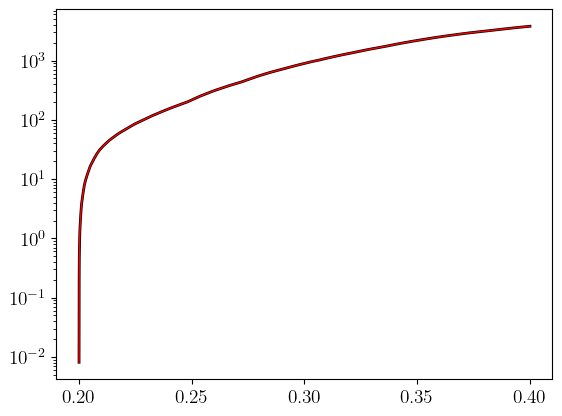

In [136]:
plt.plot(np.sort(mdwarf_table["mass"]), np.cumsum(np.sum(msorted_counts[:,[3,4]], axis=1)), lw=1, c="r", zorder=3);
plt.plot(np.sort(mdwarf_table["mass"]), np.cumsum(np.sum(msorted_counts[:,[3,4]], axis=1)), lw=2, c="k", zorder=2);
plt.yscale("log");

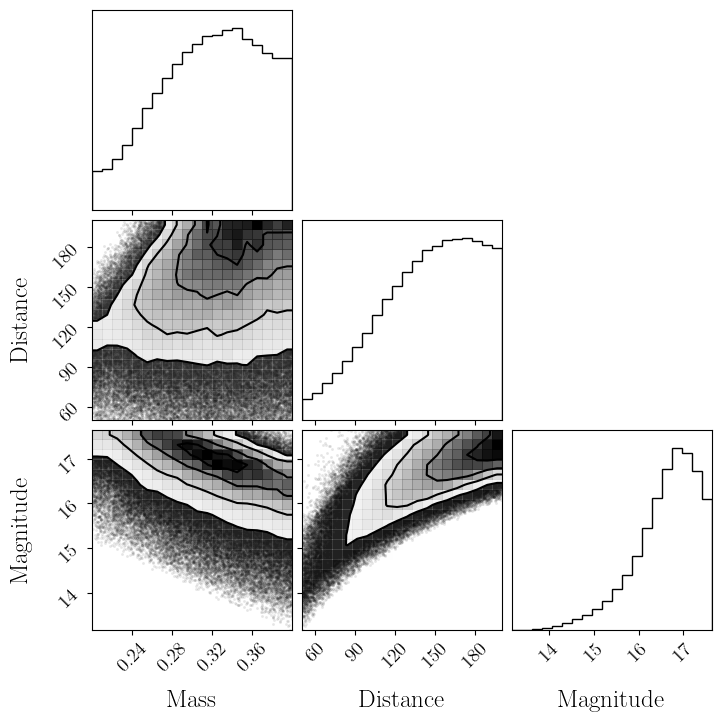

In [153]:
import corner
arr = np.array([mdwarf_table['mass'], 1000/mdwarf_table['parallax'], mdwarf_table['phot_g_mean_mag']])
arr = np.swapaxes(arr, 0,1)
cols = solution_colormap[np.searchsorted(soltypes, mdwarf_table['solution_type'])]
corner.corner(arr, labels=["Mass", "Distance", "Magnitude"]);#, color=cols);

In [148]:
soltypes = np.array(soltypes)